In [1]:
import sys
import os

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')


import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


In [2]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [3]:
X1

,300,301,302,303,304,305,306,307,308,309,...,RDkit_fr_piperdine,RDkit_fr_piperzine,RDkit_fr_pyridine,RDkit_fr_sulfide,RDkit_fr_sulfonamd,RDkit_fr_sulfone,RDkit_fr_thiazole,RDkit_fr_thiophene,RDkit_fr_unbrch_alkane,RDkit_qed
QSPRID,,,,,,,,,,,,,,,,,,,,,
A2ARDataset_000,-0.442472,0.207853,0.391181,0.222411,-0.084914,-0.652523,0.186761,-0.141471,-0.138574,0.327026,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.690353
A2ARDataset_001,-0.547015,0.326527,-0.055402,0.498394,0.059913,-0.783032,0.457208,-0.362948,0.182183,0.154815,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.488490
A2ARDataset_002,-0.183866,0.578967,0.161637,0.422820,-0.359473,-1.000239,0.778588,0.269597,0.671282,0.095040,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.389416
A2ARDataset_003,-0.255575,0.203898,0.418056,0.378673,-0.129638,-0.148893,0.742217,-0.251707,-0.097038,0.531059,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.441687
A2ARDataset_004,-0.687007,0.620376,0.137707,-0.190699,0.417505,-0.457825,0.332847,-0.721059,-0.052884,-0.030075,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.804595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2ARDataset_483,-0.108826,1.003503,0.156762,-0.109018,-0.087699,-0.874875,0.539532,0.541044,0.533539,0.117385,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.339048
A2ARDataset_484,-0.223748,0.351416,-0.098620,0.191478,0.223344,-0.828098,0.288138,-0.034601,0.138777,0.187323,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.451445
A2ARDataset_485,0.170707,0.057631,0.364865,0.143474,0.144775,0.001812,0.526527,-0.131677,0.087674,0.613961,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.743722


In [4]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [5]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit_transform(X1)
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

In [7]:
n_components

334

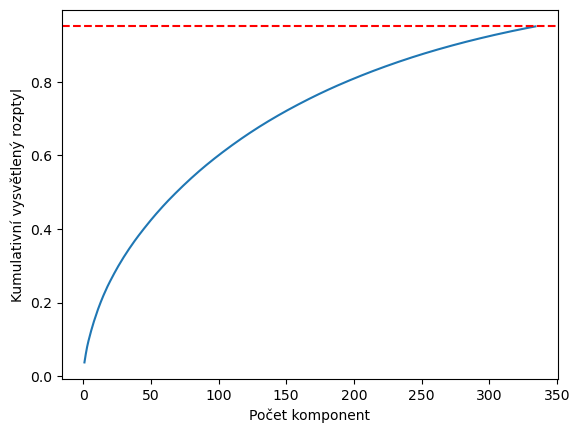

In [8]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [9]:

# Přidejte cestu k vašemu lokálnímu repozitáři
import sys
import os

# Přidání cesty k lokálnímu repozitáři na začátek sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Zkontrolujte, zda je cesta v sys.path
print(sys.path)

from importlib import reload

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected
# Znovu načtěte modul, abyste zajistili, že je správně importován
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

['/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python311.zip', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/lib-dynload', '', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages']
/home/ubuntu/Bakalarka/QSPRpred
lol


In [10]:
import optuna
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score

def objective(trial, X_train, y_train, X_val, y_val):
    """Definice cílové funkce pro Optunu"""

    # Návrh hyperparametrů pro dopřednou neuronovou síť
    params = {
        'dropout_frac': trial.suggest_float("dropout_frac", 0, 0.9),
        'patience': trial.suggest_int("patience", 10, 200),
        'tol': trial.suggest_float("tol", 1e-5, 1e-2, log=True),
        'weight_decay': trial.suggest_float("weight_decay", 1e-6, 1e-1, log=True),
        'n_epochs': trial.suggest_int("n_epochs", 200, 2000),
        'batch_size': trial.suggest_categorical("batch_size", [64, 128, 256, 512, 1024]),
        'optimizer': trial.suggest_categorical("optimizer", ["AdamW", "RMSprop"]),
        'lr': trial.suggest_categorical("lr", [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]),
        'neuron_layers': trial.suggest_categorical("neuron_layers_size", ["[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]", "[2048, 1024, 512, 256, 128, 64, 32, 16, 8]", "[4096, 1024, 256, 64, 8]", "[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]", "[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]", "[200]", "[2000]", "[2000, 1000]", "[2000, 1000, 500]", "[1000, 50]", "[4000, 2000]", "[4000, 2000, 1000, 500]", "[4000, 2000, 2000, 500]"])
    }

    neuron_layers_dict = {
        "[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]": [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        "[2048, 1024, 512, 256, 128, 64, 32, 16, 8]": [2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        "[4096, 1024, 256, 64, 8]": [4096, 1024, 256, 64, 8],
        "[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]": [4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8],
        "[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]": [4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096],
        "[200]": [200],
        "[2000]": [2000],
        "[2000, 1000]": [2000, 1000],
        "[2000, 1000, 500]": [2000, 1000, 500],
        "[1000, 50]": [1000, 50],
        "[4000, 2000]": [4000, 2000],
        "[4000, 2000, 1000, 500]": [4000, 2000, 1000, 500],
        "[4000, 2000, 2000, 500]": [4000, 2000, 2000, 500]
    }
    params['neuron_layers'] = neuron_layers_dict[params['neuron_layers']]
    opt_func = optim.AdamW if params['optimizer'] == "AdamW" else optim.RMSprop

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Model
    model = STFullyConnected(
        n_dim=X_train.shape[1],
        n_class=1,
        device=device,
        act_fun=F.selu,
        dropout_frac=params['dropout_frac'],
        patience=params['patience'],
        tol=params['tol'],  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=params['weight_decay'],
        n_epochs=params['n_epochs'],
        neuron_layers=params['neuron_layers'],  # Použití neuron_layers_size
        batch_size=params['batch_size'],
        optimizer=opt_func,
        lr=params['lr'],
    )
    # Trénink a predikce
    model.fit(X_train, y_train, X_val, y_val)
    preds = model.predict(X_val)
    preds_bin = preds > 0.5

    # Metiky
    f1 = f1_score(y_val, preds_bin)
    acc = accuracy_score(y_val, preds_bin)
    mcc = matthews_corrcoef(y_val, preds_bin)

    # Můžeš logovat i do trialu
    trial.set_user_attr("f1", f1)
    trial.set_user_attr("acc", acc)
    display(confusion_matrix(y_val, preds_bin))
    return mcc  # maximalizujeme MCC


In [ ]:
study = optuna.create_study(
    study_name="CK1_nn_without_smote",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=1000
)
print("Best MCC:", study.best_value)
print("Best parameters:", study.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study.best_trial.user_attrs["f1"])
print("Best ACC:", study.best_trial.user_attrs["acc"])

[I 2025-05-19 21:37:31,627] Using an existing study with name 'CK1_nn_without_smote' instead of creating a new one.


array([[  1, 124],
       [  0,  30]])

[I 2025-05-19 21:37:53,242] Trial 466 finished with value: 0.039477101697586135 and parameters: {'dropout_frac': 0.7983186851888682, 'patience': 37, 'tol': 0.0012754072421174482, 'weight_decay': 0.00022735427933314841, 'n_epochs': 1845, 'batch_size': 64, 'optimizer': 'AdamW', 'lr': 1, 'neuron_layers_size': '[1000, 50]'}. Best is trial 353 with value: 0.5301146385496074.


array([[105,  20],
       [  9,  21]])

[I 2025-05-19 21:38:47,945] Trial 467 finished with value: 0.48368769563251257 and parameters: {'dropout_frac': 0.2127544068681467, 'patience': 136, 'tol': 0.00037716509317637476, 'weight_decay': 0.00022735427933314841, 'n_epochs': 1758, 'batch_size': 1024, 'optimizer': 'AdamW', 'lr': 1e-05, 'neuron_layers_size': '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]'}. Best is trial 353 with value: 0.5301146385496074.


...

[I 2025-05-19 22:31:59,616] Trial 564 finished with value: 0.46238494124164903 and parameters: {'dropout_frac': 0.1957025433893808, 'patience': 30, 'tol': 1.873916027216317e-05, 'weight_decay': 0.00022735427933314841, 'n_epochs': 1380, 'batch_size': 1024, 'optimizer': 'AdamW', 'lr': 1e-05, 'neuron_layers_size': '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]'}. Best is trial 353 with value: 0.5301146385496074.


array([[105,  20],
       [  9,  21]])

[I 2025-05-19 22:32:58,479] Trial 565 finished with value: 0.48368769563251257 and parameters: {'dropout_frac': 0.4379519768750069, 'patience': 31, 'tol': 0.0004244289306916581, 'weight_decay': 2.2299866644500183e-05, 'n_epochs': 1881, 'batch_size': 64, 'optimizer': 'AdamW', 'lr': 1e-05, 'neuron_layers_size': '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]'}. Best is trial 353 with value: 0.5301146385496074.


array([[99, 26],
       [ 9, 21]])

[I 2025-05-19 22:33:10,699] Trial 566 finished with value: 0.4228827109661053 and parameters: {'dropout_frac': 0.1957025433893808, 'patience': 54, 'tol': 0.002891897488926391, 'weight_decay': 2.2299866644500183e-05, 'n_epochs': 1642, 'batch_size': 256, 'optimizer': 'AdamW', 'lr': 1e-05, 'neuron_layers_size': '[2000]'}. Best is trial 353 with value: 0.5301146385496074.


In [36]:

model = STFullyConnected(
        n_dim=X1.shape[1],
        n_class=1,
        device="cuda",
        act_fun=F.selu,
        dropout_frac=0.7587301567075606,
        patience=0.00010905325401069917,
        tol=0,  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=0.024542235145206714,
        n_epochs=403,
        neuron_layers= [200],  # Použití neuron_layers_size
        batch_size=128,
        optimizer=optim.AdamW,
        lr=1e-06,
    print_outputs= 2
    )
model.fit(X1,y1,X2,y2) #0.6084853456048988

Epoch 1 | Train Loss: 0.8106 | Valid Loss: 0.7777 | MCC: 0.1226
Epoch 2 | Train Loss: 0.7638 | Valid Loss: 0.7776 | MCC: 0.1226
Epoch 3 | Train Loss: 0.7362 | Valid Loss: 0.7774 | MCC: 0.1226
Epoch 4 | Train Loss: 0.7841 | Valid Loss: 0.7773 | MCC: 0.1226
Epoch 5 | Train Loss: 0.7705 | Valid Loss: 0.7772 | MCC: 0.1226
Epoch 6 | Train Loss: 0.8444 | Valid Loss: 0.7771 | MCC: 0.1226
Epoch 7 | Train Loss: 0.7133 | Valid Loss: 0.7769 | MCC: 0.1226
Epoch 8 | Train Loss: 0.7823 | Valid Loss: 0.7768 | MCC: 0.1226
Epoch 9 | Train Loss: 0.8025 | Valid Loss: 0.7766 | MCC: 0.1226
Epoch 10 | Train Loss: 0.7322 | Valid Loss: 0.7765 | MCC: 0.1226
Epoch 11 | Train Loss: 0.7490 | Valid Loss: 0.7763 | MCC: 0.1226
Epoch 12 | Train Loss: 0.7121 | Valid Loss: 0.7762 | MCC: 0.1226
Epoch 13 | Train Loss: 0.6762 | Valid Loss: 0.7760 | MCC: 0.1226
Epoch 14 | Train Loss: 0.8297 | Valid Loss: 0.7758 | MCC: 0.1226
Epoch 15 | Train Loss: 0.7905 | Valid Loss: 0.7755 | MCC: 0.1226
Epoch 16 | Train Loss: 0.7770 | Va

(STFullyConnected(
   (layers): ModuleList(
     (0): Linear(in_features=278, out_features=200, bias=True)
     (1): Linear(in_features=200, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.7587301567075606, inplace=False)
   (criterion): BCEWithLogitsLoss()
 ),
 402)

In [37]:
preds = model.predict(X2)
preds_bin = preds > 0.5

mcc = matthews_corrcoef(y2, preds_bin)
display(mcc)

0.5764386444017885

In [38]:
preds = model.predict(X3)
preds_bin = preds > 0.5

    # Metiky
f1 = f1_score(y3, preds_bin)
acc = accuracy_score(y3, preds_bin)
mcc = matthews_corrcoef(y3, preds_bin)

In [39]:
display(mcc) # 0.17324800323685596

0.30311535423773306

In [35]:
study_4.best_params

{'dropout_frac': 0.7587301567075606,
 'patience': 147,
 'tol': 0.00010905325401069917,
 'weight_decay': 0.024542235145206714,
 'n_epochs': 403,
 'batch_size': 128,
 'optimizer': 'AdamW',
 'lr': 1e-06,
 'neuron_layers_size': '[200]'}